<a href="https://colab.research.google.com/github/lucalomazziPolimi/Pia-Enhance-Course/blob/main/04_workshops/02_workshop_metadesign/Inverse_Design_Metamaterials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Environment Setup & Cloud Integration
This cell detects the environment and automatically fetches the specific workshop datasets from Google Drive.

In [1]:
# ==============================================================================
# environment_setup.py
# ==============================================================================
import os

# Detect environment
try:
    import google.colab
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("🌐 Google Colab detected. Initiating Cloud Setup...")

    # 1. Mount Google Drive
    drive.mount('/content/drive')

    # 2. Install dependencies
    !pip install gdown torch torchvision seaborn scikit-learn --quiet

    # 3. Automated Data Retrieval (Specific IDs provided by Prof.)
    import gdown
    print("📥 Fetching latest workshop datasets...")

    # training_data.csv
    gdown.download(id="1hTO9U5KRwnh32oxk3hk_xJOpUVVzpUL2", output="training_data.csv", quiet=True)

    # validation_data.csv
    gdown.download(id="1OPfGNlC26UhoC9ohlWp7GCP2prtEmMqp", output="validation_data.csv", quiet=True)

    print("✅ Datasets successfully integrated into workspace.")

else:
    print("💻 Local environment detected. Ensure 'training_data.csv' and 'validation_data.csv' are in your working directory.")

🌐 Google Colab detected. Initiating Cloud Setup...
Mounted at /content/drive
📥 Fetching latest workshop datasets...
✅ Datasets successfully integrated into workspace.


# Workshop: Deep Learning for Inverse Design of Metamaterials
**Luca Lomazzi | Politecnico di Milano**

---

## 1. Introduction: The Inverse Design Paradigm in Engineering

In traditional structural engineering, the workflow is strictly **Forward-oriented** (or deductive). Given a specific material, topology, and geometry (the design variables $\mathbf{x} \in \mathcal{X}$), we employ numerical methods—typically Finite Element Analysis (FEA)—to predict the resulting mechanical properties (the performance variables $\mathbf{y} \in \mathcal{Y}$). Mathematically, this is a mapping $\mathcal{F}: \mathcal{X} \rightarrow \mathcal{Y}$:

$$ \mathbf{y} = \mathcal{F}(\mathbf{x}) $$

While physically accurate, this process is computationally expensive and relies on iterative, heuristic "trial-and-error" to reach a design objective, making the exploration of massive design spaces intractable.

**Inverse Design** flips this paradigm. We define a target performance profile $\mathbf{y}^*$ and ask the system to autonomously determine the optimal geometry $\mathbf{x}^*$. We seek the inverse mapping $\mathcal{F}^{-1}: \mathcal{Y} \rightarrow \mathcal{X}$:

$$ \mathbf{x}^* = \mathcal{F}^{-1}(\mathbf{y}^*) $$

In the context of **Lattice Metamaterials**, approximating $\mathcal{F}^{-1}$ is exceptionally challenging due to three fundamental issues:
1. **High-Dimensionality and Non-Linearity**: Design parameters (e.g., strut thickness $t$, unit cell size $sz$, and discrete topology $\mathcal{T}$) interact non-linearly to govern macroscopic behavior.
2. **Discontinuous Design Spaces**: The transition from a bending-dominated cell (e.g., Kelvin) to a stretching-dominated cell (e.g., Octet/Octagonal) creates discrete, non-differentiable jumps in the performance manifold.
3. **The Ill-Posed Nature (One-to-Many Mapping)**: Inverse problems are inherently ill-posed. Multiple distinct geometries $\mathbf{x}_1, \mathbf{x}_2$ can yield nearly identical performance signatures $\mathbf{y}^*$. Standard deterministic regression models fail here, as they tend to average the conflicting targets, resulting in physically invalid, "interpolated" geometries.

### Workshop Objectives
During this session, we will architect a robust Deep Learning pipeline to solve this inverse problem by decomposing it. We will build:
- A **Forward Surrogate (PSON - Physical Surrogate Output Network)** to act as a *Digital Twin*, replacing hours of Abaqus simulation with millisecond-scale neural inference.
- An **Inverse Optimization Network (UON - Universal Optimization Network)** that circumvents the one-to-many problem via a two-stage approach: a *Topology Classification Gate* followed by a *Conditioned Geometric Regression Engine*.
- A **Rigorous Closed-Loop Validation Protocol** to verify that AI-designed materials strictly meet the mechanical specifications required for real-world impact-loading applications.

## 2. Theoretical Framework: Physics-Guided Deep Learning

To build AI models that generalize rather than just memorize, they must be grounded in the underlying physics of the system.

### 2.1 The Gibson-Ashby Scaling Laws
The macroscopic mechanical properties of cellular solids and lattice materials scale with their relative density $\bar{\rho}$ (the density of the lattice divided by the density of the solid base material, $\rho^* / \rho_s$). The **Gibson-Ashby models** dictate these power-law relationships for the effective elastic modulus ($E$) and the plastic plateau stress ($\sigma_{pl}$):

$$ \frac{E}{E_s} \approx C_1 \left( \frac{\rho^*}{\rho_s} \right)^n, \quad \frac{\sigma_{pl}}{\sigma_{ys}} \approx C_2 \left( \frac{\rho^*}{\rho_s} \right)^m $$

Where:
- $E_s$ and $\sigma_{ys}$ are the Young's modulus and yield strength of the constituent solid material.
- $C_1, C_2$ are geometric proportionality constants.
- The exponents $n$ and $m$ characterize the deformation mechanism:
  - **Bending-Dominated Lattices (e.g., Kelvin):** Deformation occurs primarily through the bending of struts. Typically, $n \approx 2$ and $m \approx 1.5$. They exhibit high energy absorption over long strokes but lower initial stiffness.
  - **Stretching-Dominated Lattices (e.g., Octagonal/Octet):** Deformation occurs via axial tension/compression of struts. Typically, $n \approx 1$ and $m \approx 1$. They provide exceptional specific stiffness and strength.

Our Neural Networks must implicitly learn to parameterize these underlying power laws directly from the raw data manifold.

### 2.2 Machine Learning Formulation
We formulate the Inverse Design as a **Multi-Task Learning (MTL)** problem. The total loss function $\mathcal{L}_{total}$ for our Geometry Engine (UON) is a weighted combination of losses targeting continuous and discrete variables.

For a target performance $\mathbf{y}$, the network predicts thickness $\hat{t}$, cell size $\hat{sz}$ (treated as a discrete class), and topology $\hat{\mathcal{T}}$:

$$ \mathcal{L}_{total} = \alpha \mathcal{L}_{MSE}(t, \hat{t}) + \beta \mathcal{L}_{CE}(sz, \hat{sz}) + \gamma \mathcal{L}_{CE}(\mathcal{T}, \hat{\mathcal{T}}) $$

Where:
- $\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^N (t_i - \hat{t}_i)^2$ ensures precise continuous sizing.
- $\mathcal{L}_{CE} = - \sum_{i=1}^N \sum_{j=1}^C c_{i,j} \log(\hat{p}_{i,j})$ handles the discrete nature of available manufacturing constraints (cell sizes) and fundamental topologies.
- The hyperparameters $\alpha, \beta, \gamma$ dictate the optimization priorities. In structural design, topology and discrete size often dictate the gross behavior, while thickness fine-tunes it.

In [2]:
# ==============================================================================
# 0. Environment Setup & Library Imports
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configure visuals for the PhD workshop
sns.set_theme(style="whitegrid", context="talk", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Computation Device active: {device.type.upper()}")

🚀 Computation Device active: CPU


## 3. Data Ingestion & Rigorous Partitioning Protocol

In Deep Learning, data leakage is a critical failure mode. To ensure scientific validity, we partition our dataset into three disjoint subsets: Training ($70\%$), Validation ($15\%$), and Test ($15\%$).

We utilize **Stratified Splitting** based on the topology class (`type_code`) to ensure physical regime consistency.

In [3]:
# ==============================================================================
# 1. Data Ingestion & Stratified 70/15/15 Splitting
# ==============================================================================
try:
    df_train_raw = pd.read_csv('training_data.csv')
    df_val_raw = pd.read_csv('validation_data.csv')

    df_full = pd.concat([df_train_raw, df_val_raw], ignore_index=True)
    df_full = df_full.drop_duplicates().reset_index(drop=True)

    df_tr, df_temp = train_test_split(
        df_full, test_size=0.30, random_state=42, stratify=df_full['type_code']
    )
    df_val, df_te = train_test_split(
        df_temp, test_size=0.50, random_state=42, stratify=df_temp['type_code']
    )

    X_cols = ['E_mod', 'dens_strain', 'energy_abs', 'plateau_stress']
    Y_cols = ['thickness', 'cell_size', 'type_code']

    print(f"✅ Data Partitioning Successful!")
    print(f"   - Training Set:   {len(df_tr)} samples")
    print(f"   - Validation Set: {len(df_val)} samples")
    print(f"   - Test Set:       {len(df_te)} samples")

except FileNotFoundError:
    print("❌ Error: Dataset CSV files missing.")

✅ Data Partitioning Successful!
   - Training Set:   1206 samples
   - Validation Set: 259 samples
   - Test Set:       259 samples


## 4. Phase 1: Exhaustive Statistical Analysis (Exploratory Data Analysis)

Before designing neural architectures, we must map the statistical landscape of our physical data.

### 4.1 Statistical Moments: Skewness and Kurtosis
Beyond mean and variance, we analyze **Skewness ($S$)** and **Kurtosis ($K$)** to detect distribution asymmetry and high-performance outliers.

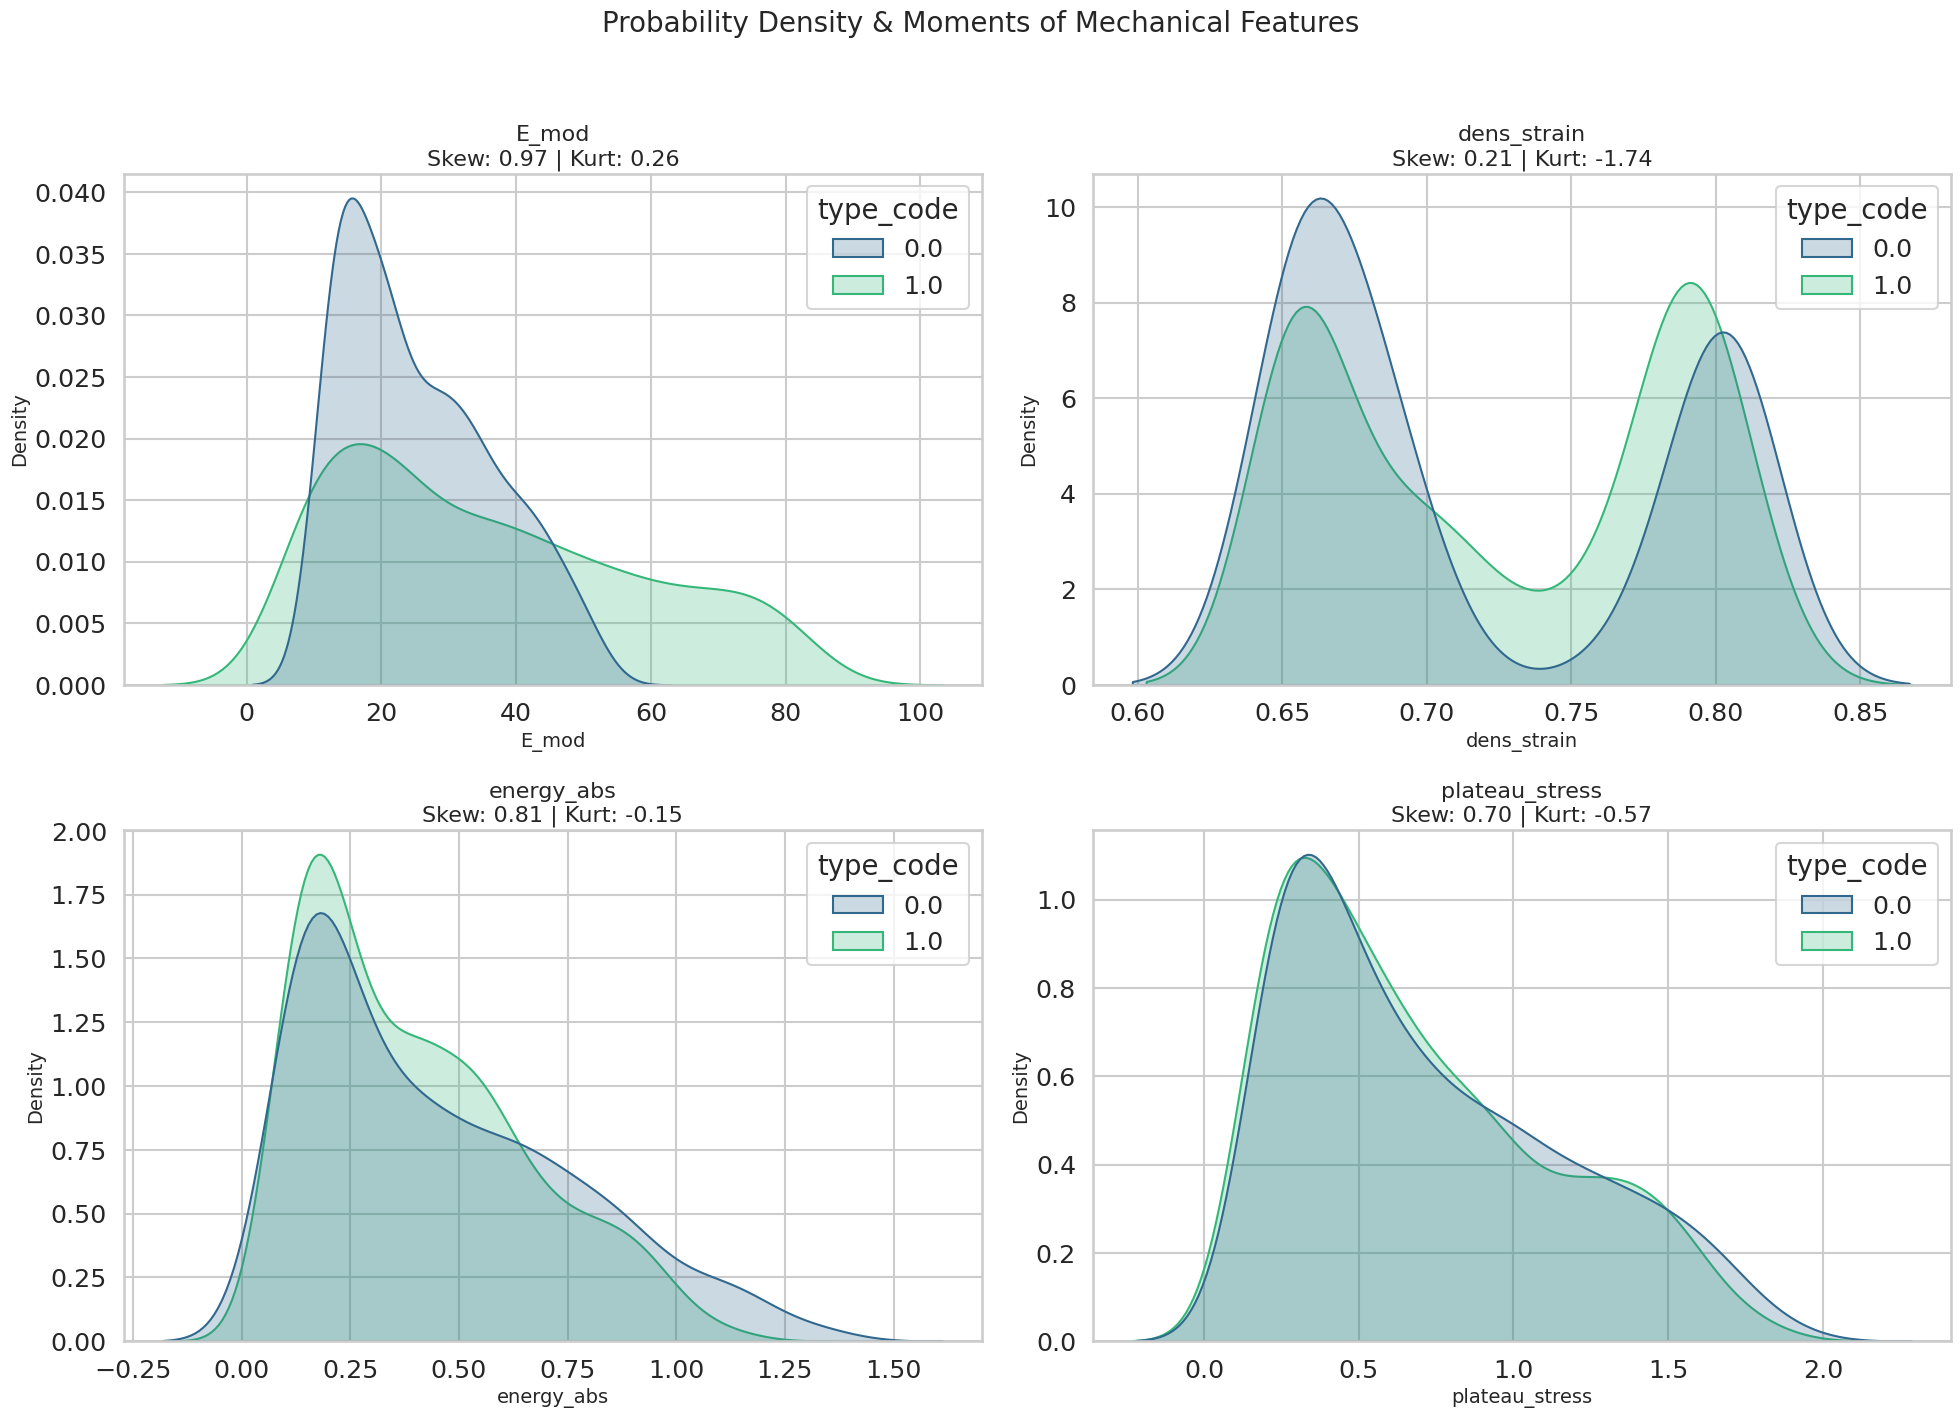

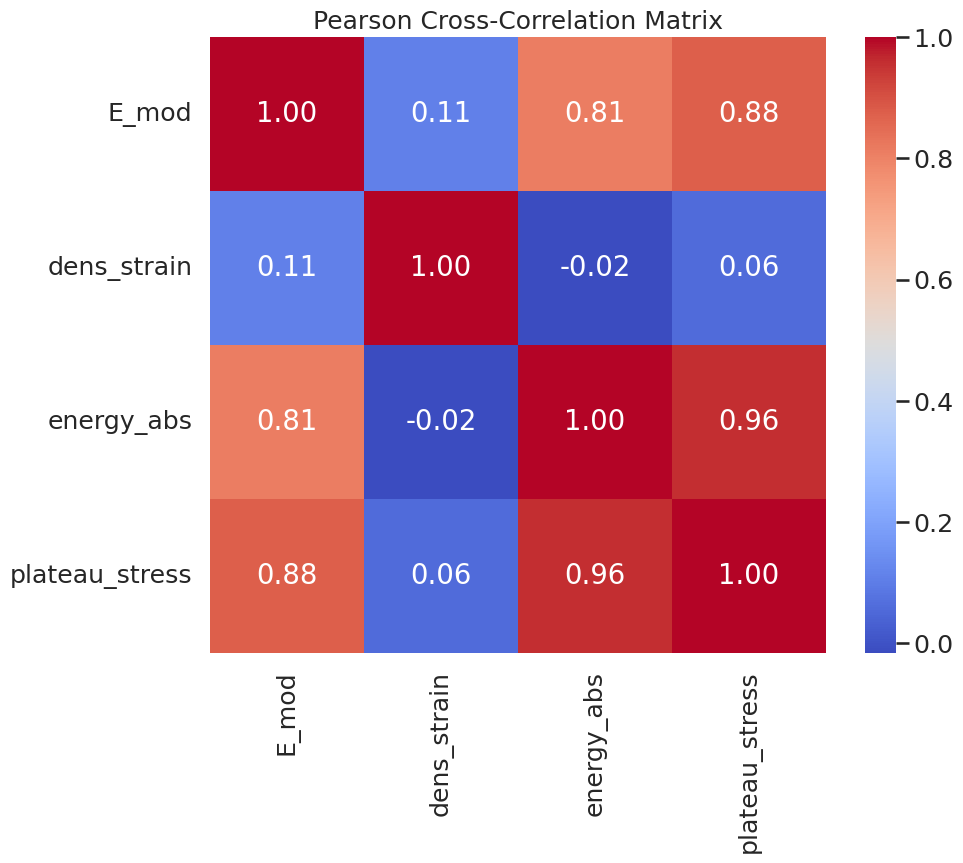

In [4]:
# ==============================================================================
# Phase 1: Statistical Moments & Manifold Analysis
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(X_cols):
    sns.kdeplot(data=df_tr, x=col, hue='type_code', fill=True, palette='viridis', common_norm=False, ax=axes[i])
    s = skew(df_tr[col])
    k = kurtosis(df_tr[col])
    axes[i].set_title(f"{col}\nSkew: {s:.2f} | Kurt: {k:.2f}")

plt.suptitle("Probability Density & Moments of Mechanical Features", fontsize=20, y=1.02)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_tr[X_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Pearson Cross-Correlation Matrix", fontsize=18); plt.show()

## 5. Phase 2: Architecting the Forward Surrogate (PSON)

The **Physical Surrogate Output Network (PSON)** acts as our Digital Twin, approximating the non-linear FEM mapping $\mathcal{F}(\mathbf{x}) \approx \tilde{\mathcal{F}}_{\theta}(\mathbf{x})$.

### 5.1 Objective Function and Metrics
We minimize the Mean Squared Error (MSE) over the normalized feature space:
$$ \mathcal{L}_{PSON}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \left\| \mathbf{y}_i - \tilde{\mathcal{F}}_{\theta}(\mathbf{x}_i) \right\|_2^2 $$

Training PSON Surrogate Digital Twin...


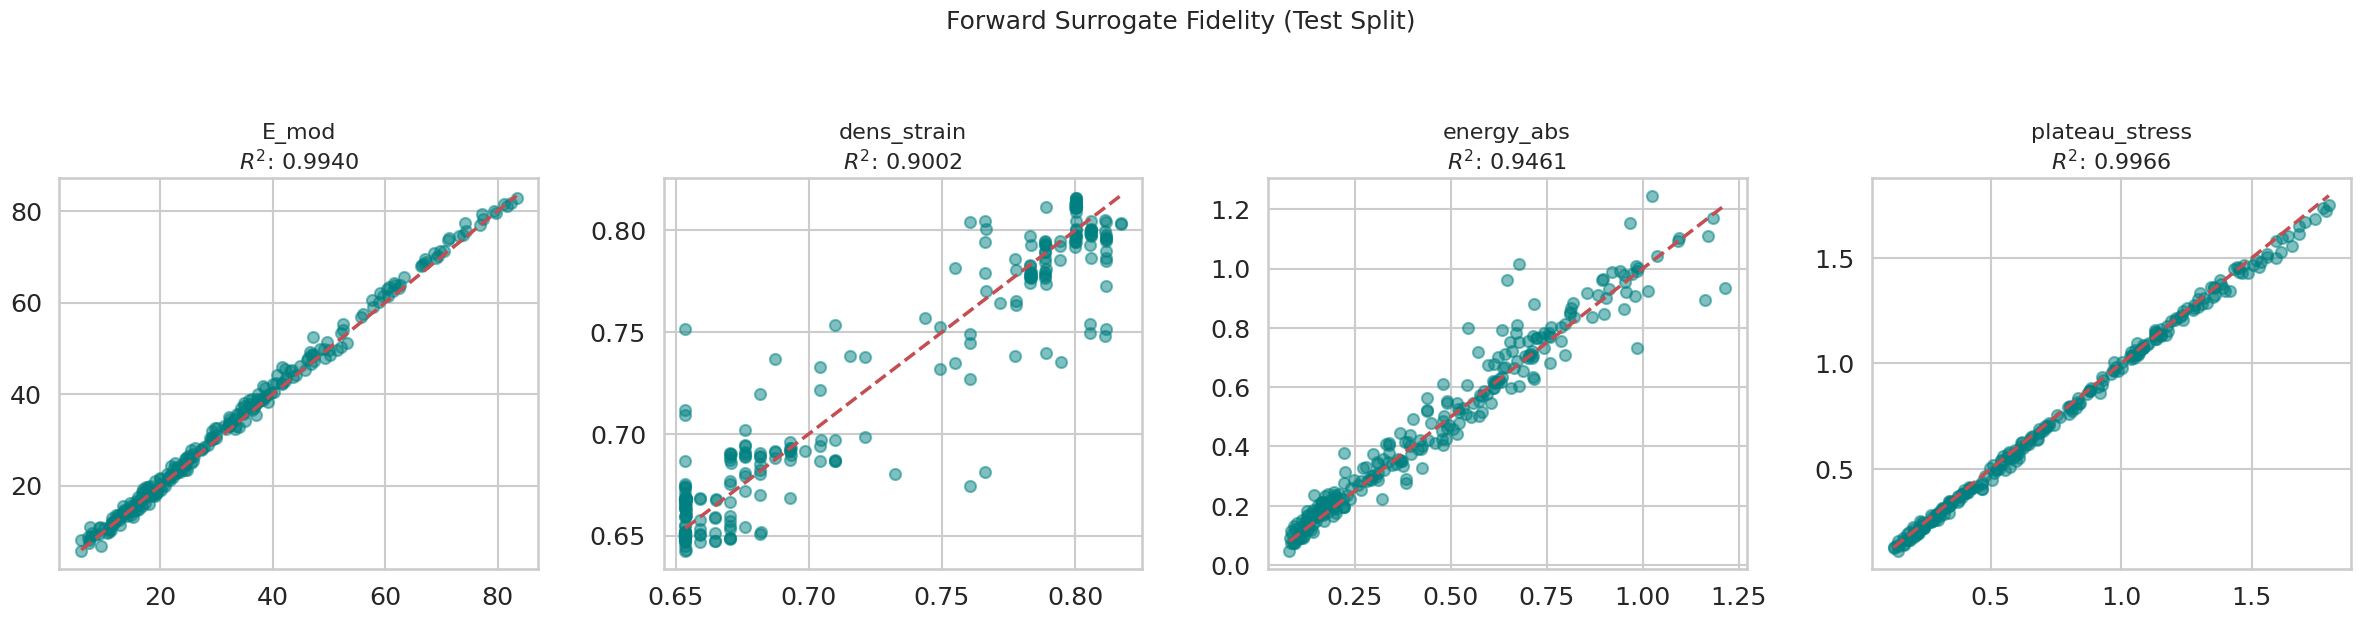

In [5]:
# ==============================================================================
# Phase 2: Forward Surrogate (PSON) Implementation
# ==============================================================================

class PSON(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), nn.LeakyReLU(0.1), nn.BatchNorm1d(256),
            nn.Linear(256, 256), nn.LeakyReLU(0.1), nn.BatchNorm1d(256),
            nn.Linear(256, 128), nn.LeakyReLU(0.1),
            nn.Linear(128, 4)
        )
    def forward(self, x): return self.net(x)

s_pson_in = MinMaxScaler().fit(df_tr[Y_cols])
s_pson_out = MinMaxScaler().fit(df_tr[X_cols])

def prep_pson_tensors(df):
    X = torch.tensor(s_pson_in.transform(df[Y_cols]), dtype=torch.float32).to(device)
    y = torch.tensor(s_pson_out.transform(df[X_cols]), dtype=torch.float32).to(device)
    return X, y

X_p_tr, y_p_tr = prep_pson_tensors(df_tr)
X_p_val, y_p_val = prep_pson_tensors(df_val)
X_p_te, _ = prep_pson_tensors(df_te)
y_p_te_real = df_te[X_cols].values

pson = PSON().to(device)
optimizer = optim.Adam(pson.parameters(), lr=1e-3)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(X_p_tr, y_p_tr), batch_size=128, shuffle=True)

print("Training PSON Surrogate Digital Twin...")
for epoch in range(120):
    pson.train()
    for xb, yb in loader:
        optimizer.zero_grad(); loss = criterion(pson(xb), yb); loss.backward(); optimizer.step()

pson.eval()
with torch.no_grad():
    preds_p_real = s_pson_out.inverse_transform(pson(X_p_te).cpu().numpy())

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for i, col in enumerate(X_cols):
    r2 = r2_score(y_p_te_real[:, i], preds_p_real[:, i])
    axes[i].scatter(y_p_te_real[:, i], preds_p_real[:, i], alpha=0.5, color='teal')
    axes[i].plot([y_p_te_real[:, i].min(), y_p_te_real[:, i].max()], [y_p_te_real[:, i].min(), y_p_te_real[:, i].max()], 'r--')
    axes[i].set_title(f"{col}\n$R^2$: {r2:.4f}")

plt.suptitle("Forward Surrogate Fidelity (Test Split)", fontsize=18, y=1.05)
plt.tight_layout(); plt.show()

## 6. Phase 3: The Inverse Engine - Topology Gate (UON Classifier)

Addressing the ill-posed nature of inverse design requires partitioning the manifold by Topology $\mathcal{T}$.

### 6.1 Objective Function
We train this gate using **Categorical Cross-Entropy (CE)**:
$$ \mathcal{L}_{CE} = - \sum_{i=1}^N \sum_{k=1}^C y_{i,k} \log(\hat{p}_{i,k}) $$

Training Topology Classification Gate...


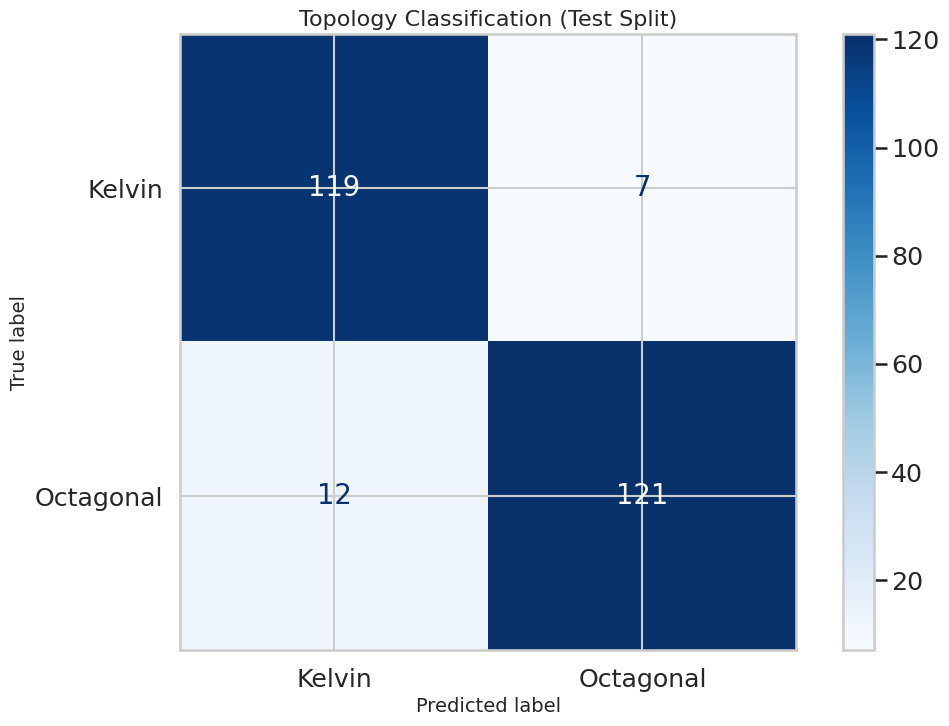

In [6]:
# ==============================================================================
# Phase 3: Topology Gate (UON-Type)
# ==============================================================================

class UONType(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.LeakyReLU(0.1), nn.BatchNorm1d(128),
            nn.Linear(128, 64), nn.LeakyReLU(0.1), nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)

s_uon_in = MinMaxScaler().fit(df_tr[X_cols])

def prep_uontype_tensors(df):
    X = torch.tensor(s_uon_in.transform(df[X_cols]), dtype=torch.float32).to(device)
    y = torch.tensor(df['type_code'].values, dtype=torch.long).to(device)
    return X, y

X_ut_tr, y_ut_tr = prep_uontype_tensors(df_tr)
X_ut_te, y_ut_te_real = prep_uontype_tensors(df_te)

uon_t = UONType().to(device)
optimizer_t = optim.Adam(uon_t.parameters(), lr=2e-3)
criterion_t = nn.CrossEntropyLoss()

print("Training Topology Classification Gate...")
for epoch in range(100):
    uon_t.train(); optimizer_t.zero_grad()
    loss = criterion_t(uon_t(X_ut_tr), y_ut_tr); loss.backward(); optimizer_t.step()

uon_t.eval()
with torch.no_grad():
    preds_te_t = torch.argmax(uon_t(X_ut_te), dim=1).cpu().numpy()
    y_ut_te_real = y_ut_te_real.cpu().numpy()

cm = confusion_matrix(y_ut_te_real, preds_te_t)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Kelvin', 'Octagonal'])
disp.plot(cmap='Blues'); plt.title("Topology Classification (Test Split)"); plt.show()

## 7. Phase 4: The Inverse Engine - Geometry Core (UON Core)

The **UON Core** predicts geometric parameters conditioned on the topology.

### 7.1 Multi-Task Loss Formulation
$$ \mathcal{L}_{Core} = \alpha \cdot \text{MSE}(t, \hat{t}) + \beta \cdot \text{CE}(sz, \hat{sz}_{logits}) $$

Training Inverse Geometry Engine...


/tmp/ipykernel_945/446885555.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=sz_pred == df_te['cell_size'], palette='Set2', ax=ax2)


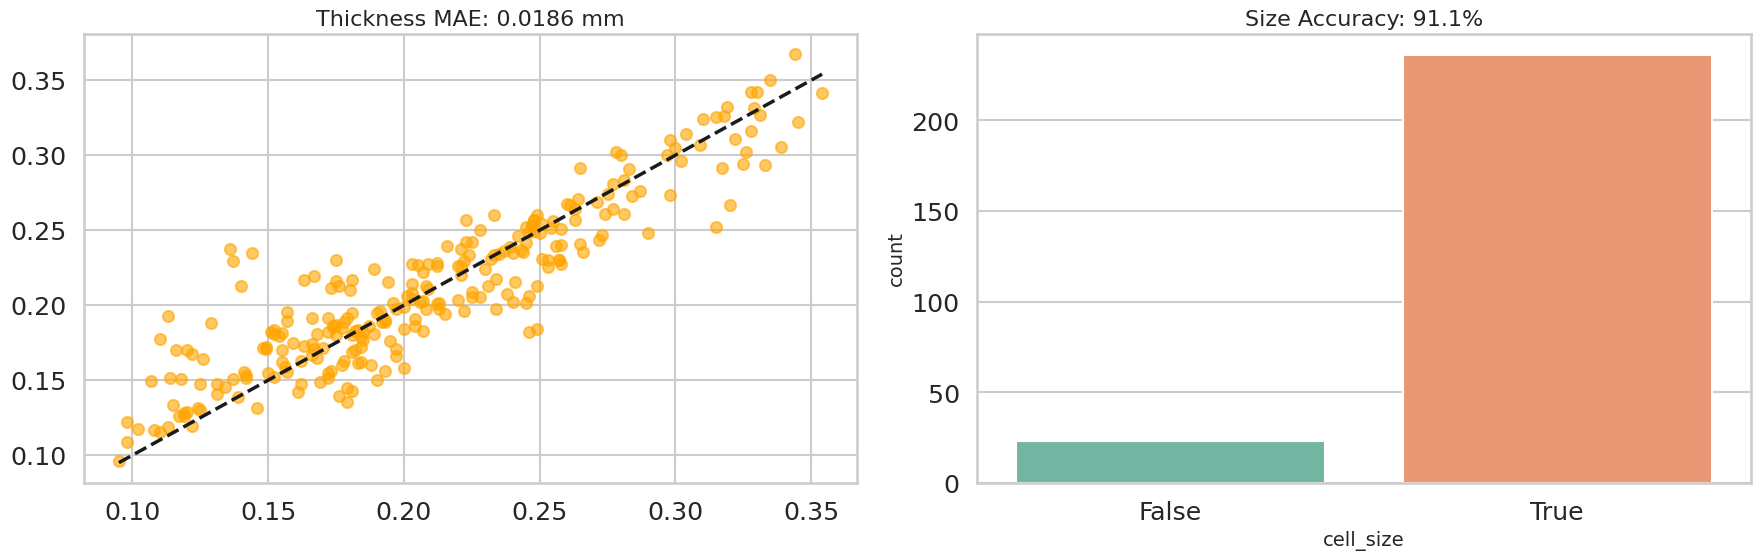

In [7]:
# ==============================================================================
# Phase 4: Geometry Engine (UON-Core)
# ==============================================================================

ALLOWED_SIZES = sorted(df_full['cell_size'].unique().tolist())
le = LabelEncoder().fit(ALLOWED_SIZES)

class UONCore(nn.Module):
    def __init__(self, n_sizes):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(6, 256), nn.LeakyReLU(0.1), nn.BatchNorm1d(256),
            nn.Linear(256, 128), nn.LeakyReLU(0.1)
        )
        self.th_head = nn.Linear(128, 1)
        self.sz_head = nn.Linear(128, n_sizes)

    def forward(self, x_perf, x_topo):
        h = self.backbone(torch.cat([x_perf, x_topo], dim=1))
        return self.th_head(h), self.sz_head(h)

s_th = MinMaxScaler().fit(df_tr[['thickness']])

def prep_uoncore_tensors(df):
    X_perf = torch.tensor(s_uon_in.transform(df[X_cols]), dtype=torch.float32).to(device)
    topo_indices = torch.tensor(df['type_code'].values, dtype=torch.long).to(device)
    X_topo = F.one_hot(topo_indices, num_classes=2).float().to(device)

    Y_th = torch.tensor(s_th.transform(df[['thickness']]), dtype=torch.float32).to(device)
    Y_sz = torch.tensor(le.transform(df['cell_size']), dtype=torch.long).to(device)
    return X_perf, X_topo, Y_th, Y_sz

X_perf_tr, X_topo_tr, Y_th_tr, Y_sz_tr = prep_uoncore_tensors(df_tr)
X_perf_te, X_topo_te, Y_th_te_real, Y_sz_te_real = prep_uoncore_tensors(df_te)

uon_c = UONCore(len(ALLOWED_SIZES)).to(device)
optimizer_c = optim.Adam(uon_c.parameters(), lr=1e-3)
loader_c = DataLoader(TensorDataset(X_perf_tr, X_topo_tr, Y_th_tr, Y_sz_tr), batch_size=64, shuffle=True)

print("Training Inverse Geometry Engine...")
for epoch in range(200):
    uon_c.train()
    for xp, xt, yt, yz in loader_c:
        optimizer_c.zero_grad(); p_th, p_sz = uon_c(xp, xt)
        loss = 2.0 * nn.MSELoss()(p_th, yt) + 1.0 * nn.CrossEntropyLoss()(p_sz, yz)
        loss.backward(); optimizer_c.step()

uon_c.eval()
with torch.no_grad():
    p_th, p_sz = uon_c(X_perf_te, X_topo_te)
    th_pred = s_th.inverse_transform(p_th.cpu().numpy()).flatten()
    sz_pred = le.inverse_transform(torch.argmax(p_sz, dim=1).cpu().numpy())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.scatter(df_te['thickness'], th_pred, color='orange', alpha=0.6)
ax1.plot([df_te['thickness'].min(), df_te['thickness'].max()], [df_te['thickness'].min(), df_te['thickness'].max()], 'k--')
ax1.set_title(f"Thickness MAE: {mean_absolute_error(df_te['thickness'], th_pred):.4f} mm")
sns.countplot(x=sz_pred == df_te['cell_size'], palette='Set2', ax=ax2)
ax2.set_title(f"Size Accuracy: {(sz_pred == df_te['cell_size']).mean()*100:.1f}%")
plt.tight_layout(); plt.show()

## 8. Phase 5: High-Fidelity Closed-Loop Validation

Verifying design: **Request** $\mathbf{y}^* \to$ **Inverse Phase** (UON) $\to$ **Forward Phase** (PSON) $\to$ **Achieved Performance** $\hat{\mathbf{y}}$.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


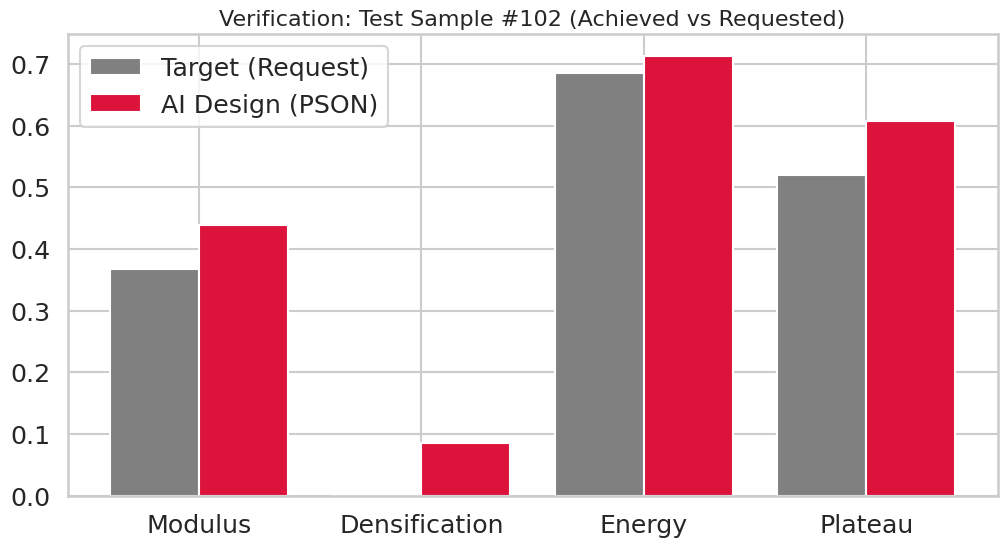

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


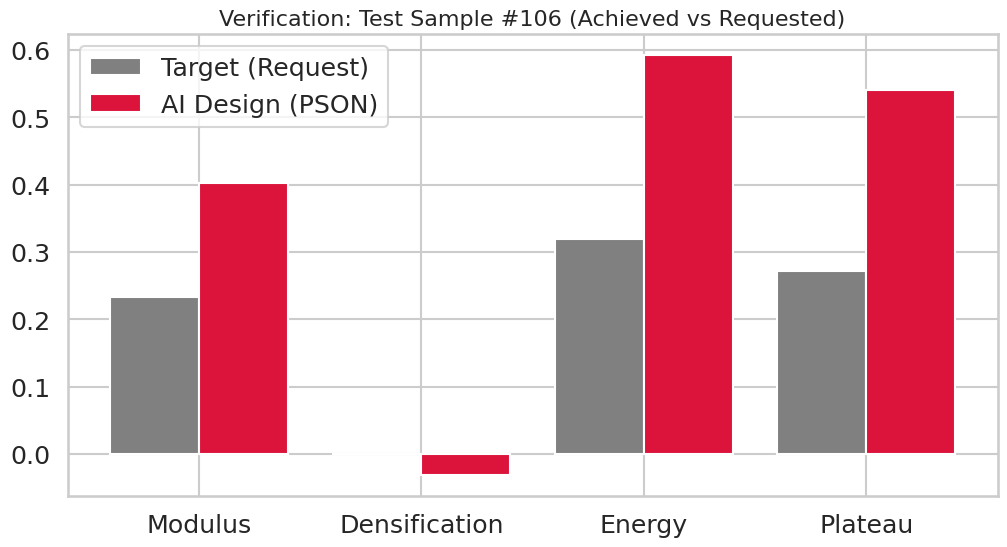

In [10]:
# ==============================================================================
# Phase 5: Closed-Loop Validation
# ==============================================================================
def execute_closed_loop(idx):
    target_sample = df_te.iloc[idx]
    y_star_real = target_sample[X_cols].values
    y_star_N = torch.tensor(s_uon_in.transform([y_star_real]), dtype=torch.float32).to(device)

    with torch.no_grad():
        t_logits = uon_t(y_star_N)
        pred_t_idx = torch.argmax(t_logits, dim=1)
        pred_t_oh = F.one_hot(pred_t_idx, num_classes=2).float()
        p_th, p_sz = uon_c(y_star_N, pred_t_oh)

        d_th = s_th.inverse_transform(p_th.cpu().numpy())[0][0]
        d_sz = ALLOWED_SIZES[torch.argmax(p_sz, dim=1).item()]
        d_type = pred_t_idx.item()

        geom_N = torch.tensor(s_pson_in.transform([[d_th, d_sz, d_type]]), dtype=torch.float32).to(device)
        y_achieved_real = s_pson_out.inverse_transform(pson(geom_N).cpu().numpy())[0]

    plt.figure(figsize=(12, 6))
    plt.bar(np.arange(4)-0.2, s_uon_in.transform([y_star_real])[0], 0.4, label='Target (Request)', color='gray')
    plt.bar(np.arange(4)+0.2, s_uon_in.transform([y_achieved_real])[0], 0.4, label='AI Design (PSON)', color='crimson')
    plt.xticks(np.arange(4), ['Modulus', 'Densification', 'Energy', 'Plateau'])
    plt.title(f"Verification: Test Sample #{idx} (Achieved vs Requested)")
    plt.legend(); plt.show()

np.random.seed(42)
for _ in range(2): execute_closed_loop(np.random.randint(len(df_te)))

## 9. Conclusions & Synthesis
We have implemented a rigorous, physics-guided Deep Learning pipeline for Inverse Design. The forward Digital Twin enables millisecond evaluation, while the conditioned inverse engine navigates the complex geometric manifold to meet mechanical specifications.